In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

## Problem Statement
A retail company “ABC Private Limited” wants to understand the customer purchase behaviour (specifically, purchase amount) against various products of different categories. They have shared purchase summary of various customers for selected high volume products from last month. The data set also contains customer demographics (age, gender, marital status, city_type, stay_in_current_city), product details (product_id and product category) and Total purchase_amount from last month.

Now, they want to build a model to predict the purchase amount of customer against various products which will help them to create personalized offer for customers against different products.


In [2]:
df_train=pd.read_csv('train.csv')
df_train.head(2)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200


In [3]:
df_test=pd.read_csv('test.csv')
df_test.head(2)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3
0,1000004,P00128942,M,46-50,7,B,2,1,1,11.0,NaN
1,1000009,P00113442,M,26-35,17,C,0,0,3,5.0,NaN


In [4]:
df = pd.concat([df_train, df_test], ignore_index=True)
df.head(2)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370.0
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200.0


In [5]:
df.shape

(783667, 12)

In [6]:
df.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            245982
Product_Category_3            545809
Purchase                      233599
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783667 entries, 0 to 783666
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     783667 non-null  int64  
 1   Product_ID                  783667 non-null  object 
 2   Gender                      783667 non-null  object 
 3   Age                         783667 non-null  object 
 4   Occupation                  783667 non-null  int64  
 5   City_Category               783667 non-null  object 
 6   Stay_In_Current_City_Years  783667 non-null  object 
 7   Marital_Status              783667 non-null  int64  
 8   Product_Category_1          783667 non-null  int64  
 9   Product_Category_2          537685 non-null  float64
 10  Product_Category_3          237858 non-null  float64
 11  Purchase                    550068 non-null  float64
dtypes: float64(3), int64(4), object(5)
memory usage: 71.7+ MB


In [8]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,7.836670e+05,783667.000000,783667.000000,783667.000000,537685.000000,237858.000000,550068.000000
mean,1.003029e+06,8.079300,0.409777,5.366196,9.844506,12.668605,9263.968713
std,1.727267e+03,6.522206,0.491793,3.878160,5.089093,4.125510,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001519e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003075e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


In [9]:
df.drop(['User_ID'],axis=1,inplace=True)

In [10]:
df['Gender']=df['Gender'].map({'F':0,'M':1})
df.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00069042,0,0-17,10,A,2,0,3,NaN,NaN,8370.0
1,P00248942,0,0-17,10,A,2,0,1,6.0,14.0,15200.0
2,P00087842,0,0-17,10,A,2,0,12,NaN,NaN,1422.0
3,P00085442,0,0-17,10,A,2,0,12,14.0,NaN,1057.0
4,P00285442,1,55+,16,C,4+,0,8,NaN,NaN,7969.0


<Axes: xlabel='Age'>

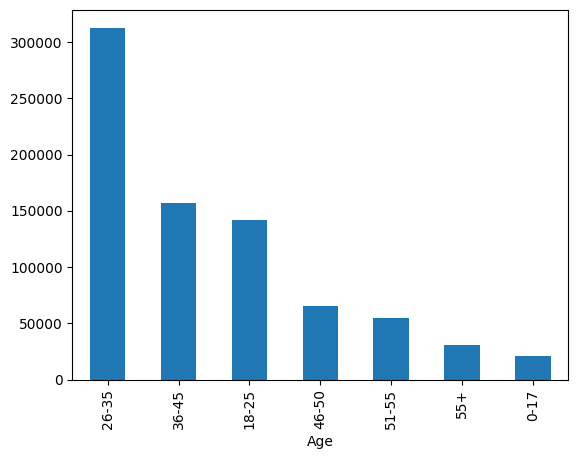

In [11]:
df['Age'].value_counts().plot(kind='bar')

In [12]:
df['Age']=df['Age'].map({'0-17':1,'18-25':2,'26-35':3,'36-45':4,'46-50':5,'51-55':6,'55+':7})
df.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00069042,0,1,10,A,2,0,3,NaN,NaN,8370.0
1,P00248942,0,1,10,A,2,0,1,6.0,14.0,15200.0
2,P00087842,0,1,10,A,2,0,12,NaN,NaN,1422.0
3,P00085442,0,1,10,A,2,0,12,14.0,NaN,1057.0
4,P00285442,1,7,16,C,4+,0,8,NaN,NaN,7969.0


In [13]:
# from sklearn import preprocessing

# le=preprocessing.LabelEncoder()

# df['Age']=le.fit_transform(df['Age'])
# df['Age'].unique()

In [14]:
df_city=pd.get_dummies(df['City_Category'],drop_first=True,dtype=int)
df_city.head()

,B,C
0,0,0
1,0,0
2,0,0
3,0,0
4,0,1


In [15]:
df=pd.concat([df,df_city],axis=1)
df.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,B,C
0,P00069042,0,1,10,A,2,0,3,NaN,NaN,8370.0,0,0
1,P00248942,0,1,10,A,2,0,1,6.0,14.0,15200.0,0,0
2,P00087842,0,1,10,A,2,0,12,NaN,NaN,1422.0,0,0
3,P00085442,0,1,10,A,2,0,12,14.0,NaN,1057.0,0,0
4,P00285442,1,7,16,C,4+,0,8,NaN,NaN,7969.0,0,1


In [16]:
df.drop('City_Category',axis=1,inplace=True)
df.head()

,Product_ID,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,B,C
0,P00069042,0,1,10,2,0,3,NaN,NaN,8370.0,0,0
1,P00248942,0,1,10,2,0,1,6.0,14.0,15200.0,0,0
2,P00087842,0,1,10,2,0,12,NaN,NaN,1422.0,0,0
3,P00085442,0,1,10,2,0,12,14.0,NaN,1057.0,0,0
4,P00285442,1,7,16,4+,0,8,NaN,NaN,7969.0,0,1


In [17]:
df['Product_Category_2'].unique()

array([nan,  6., 14.,  2.,  8., 15., 16., 11.,  5.,  3.,  4., 12.,  9.,
       10., 17., 13.,  7., 18.])

In [18]:
df['Product_Category_2'].value_counts()

Product_Category_2
8.0     91317
14.0    78834
2.0     70498
16.0    61687
15.0    54114
5.0     37165
4.0     36705
6.0     23575
11.0    20230
17.0    19104
13.0    15054
9.0      8177
12.0     7801
10.0     4420
3.0      4123
18.0     4027
7.0       854
Name: count, dtype: int64

In [19]:
df['Product_Category_2'].mode()[0]

np.float64(8.0)

In [20]:
df['Product_Category_2']=df['Product_Category_2'].fillna(df['Product_Category_2'].mode()[0])
df['Product_Category_2'].isnull().sum()

np.int64(0)

In [21]:
df.head()

,Product_ID,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,B,C
0,P00069042,0,1,10,2,0,3,8.0,NaN,8370.0,0,0
1,P00248942,0,1,10,2,0,1,6.0,14.0,15200.0,0,0
2,P00087842,0,1,10,2,0,12,8.0,NaN,1422.0,0,0
3,P00085442,0,1,10,2,0,12,14.0,NaN,1057.0,0,0
4,P00285442,1,7,16,4+,0,8,8.0,NaN,7969.0,0,1


In [22]:
df['Product_Category_3'].unique()

array([nan, 14., 17.,  5.,  4., 16., 15.,  8.,  9., 13.,  6., 12.,  3.,
       18., 11., 10.])

In [23]:
df['Product_Category_3'].value_counts()

Product_Category_3
16.0    46469
15.0    39968
14.0    26283
17.0    23818
5.0     23799
8.0     17861
9.0     16532
12.0    13115
13.0     7849
6.0      6888
18.0     6621
4.0      2691
11.0     2585
10.0     2501
3.0       878
Name: count, dtype: int64

In [24]:
df['Product_Category_3'].mode()[0]

np.float64(16.0)

In [25]:
df['Product_Category_3']=df['Product_Category_3'].fillna(df['Product_Category_3'].mode()[0])
df['Product_Category_3'].isnull().sum()

np.int64(0)

In [26]:
df.head()

,Product_ID,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,B,C
0,P00069042,0,1,10,2,0,3,8.0,16.0,8370.0,0,0
1,P00248942,0,1,10,2,0,1,6.0,14.0,15200.0,0,0
2,P00087842,0,1,10,2,0,12,8.0,16.0,1422.0,0,0
3,P00085442,0,1,10,2,0,12,14.0,16.0,1057.0,0,0
4,P00285442,1,7,16,4+,0,8,8.0,16.0,7969.0,0,1


In [27]:
df['Stay_In_Current_City_Years'].unique()

array(['2', '4+', '3', '1', '0'], dtype=object)

In [28]:
df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].str.replace('+', '', regex=False)

In [29]:
df['Stay_In_Current_City_Years']=df['Stay_In_Current_City_Years'].astype('Int32')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783667 entries, 0 to 783666
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Product_ID                  783667 non-null  object 
 1   Gender                      783667 non-null  int64  
 2   Age                         783667 non-null  int64  
 3   Occupation                  783667 non-null  int64  
 4   Stay_In_Current_City_Years  783667 non-null  Int32  
 5   Marital_Status              783667 non-null  int64  
 6   Product_Category_1          783667 non-null  int64  
 7   Product_Category_2          783667 non-null  float64
 8   Product_Category_3          783667 non-null  float64
 9   Purchase                    550068 non-null  float64
 10  B                           783667 non-null  int64  
 11  C                           783667 non-null  int64  
dtypes: Int32(1), float64(3), int64(7), object(1)
memory usage: 69.5+ MB


In [30]:
# sns.pairplot(df)

<Axes: xlabel='Age', ylabel='Purchase'>

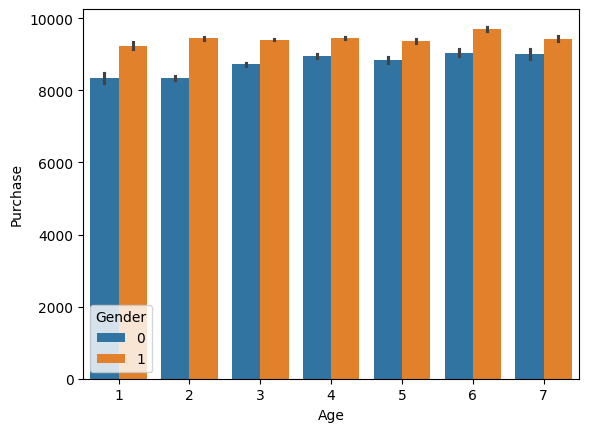

In [31]:
sns.barplot(x='Age',y='Purchase',hue='Gender',data=df)

<Axes: xlabel='Occupation', ylabel='Purchase'>

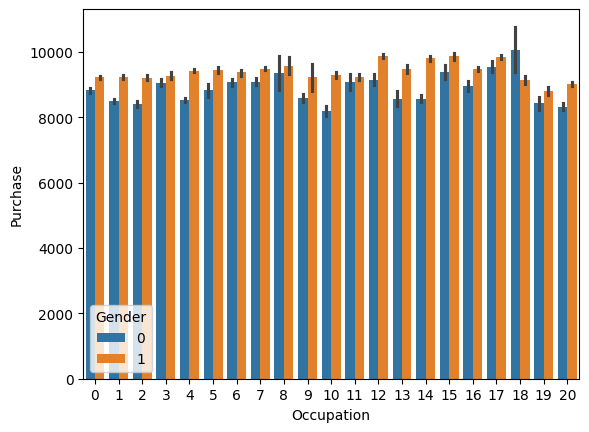

In [32]:
sns.barplot(x='Occupation',y='Purchase',hue='Gender',data=df)

<Axes: xlabel='Product_Category_1', ylabel='Purchase'>

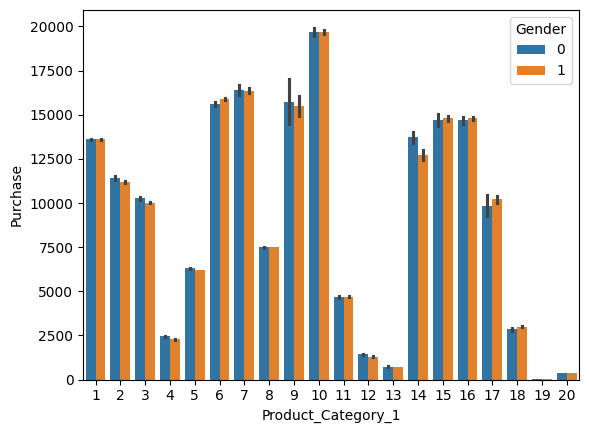

In [33]:
sns.barplot(x='Product_Category_1',y='Purchase',hue='Gender',data=df)

<Axes: xlabel='Product_Category_1', ylabel='count'>

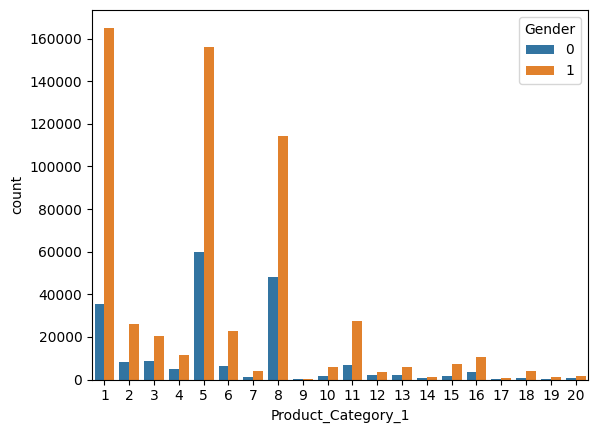

In [34]:
sns.countplot(x='Product_Category_1',hue='Gender',data=df)

<Axes: xlabel='Product_Category_2', ylabel='Purchase'>

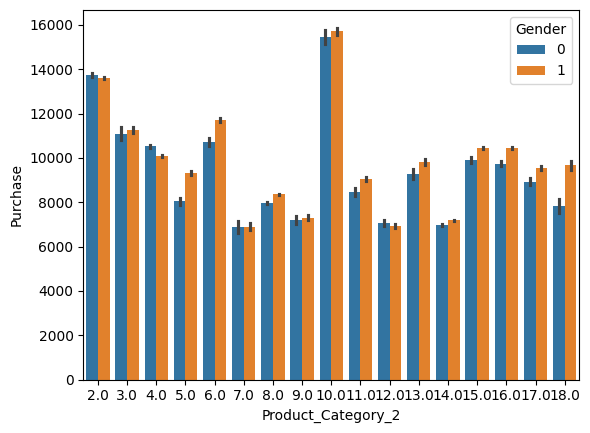

In [35]:
sns.barplot(x='Product_Category_2',y='Purchase',hue='Gender',data=df)

<Axes: xlabel='Product_Category_3', ylabel='Purchase'>

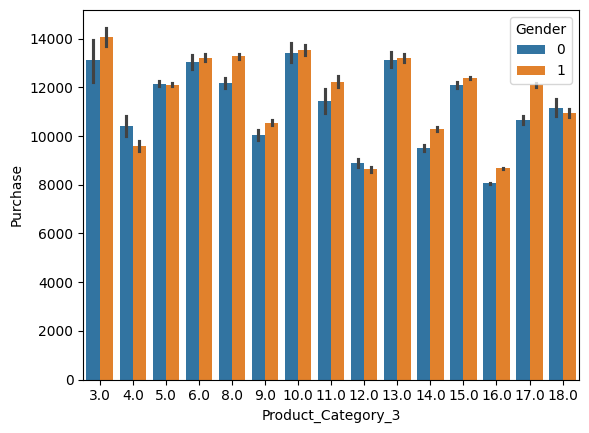

In [36]:
sns.barplot(x='Product_Category_3',y='Purchase',hue='Gender',data=df)

Feature Scaling

In [37]:
df_test=df[df['Purchase'].isnull()]

In [38]:
df_train=df[~df['Purchase'].isnull()]

In [39]:
X=df_train.drop('Purchase',axis=1)
y=df_train['Purchase']

In [40]:
X.shape

(550068, 11)

In [41]:
X

,Product_ID,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,B,C
0,P00069042,0,1,10,2,0,3,8.0,16.0,0,0
1,P00248942,0,1,10,2,0,1,6.0,14.0,0,0
2,P00087842,0,1,10,2,0,12,8.0,16.0,0,0
3,P00085442,0,1,10,2,0,12,14.0,16.0,0,0
4,P00285442,1,7,16,4,0,8,8.0,16.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
550063,P00372445,1,6,13,1,1,20,8.0,16.0,1,0
550064,P00375436,0,3,1,3,0,20,8.0,16.0,0,1
550065,P00375436,0,3,15,4,1,20,8.0,16.0,1,0
550066,P00375436,0,7,1,2,0,20,8.0,16.0,0,1


In [42]:
y.shape

(550068,)

In [43]:
y

0          8370.0
1         15200.0
2          1422.0
3          1057.0
4          7969.0
           ...   
550063      368.0
550064      371.0
550065      137.0
550066      365.0
550067      490.0
Name: Purchase, Length: 550068, dtype: float64

In [44]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)

In [45]:
X_train.drop('Product_ID',axis=1,inplace=True)
X_test.drop('Product_ID',axis=1,inplace=True)

In [46]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [47]:
# Step 1 — pehle yeh features df mein banao (drop se pehle)
product_avg = df.groupby('Product_ID')['Purchase'].mean()
product_count = df.groupby('Product_ID')['Purchase'].count()

df['Product_Avg_Purchase']   = df['Product_ID'].map(product_avg)
df['Product_Purchase_Count'] = df['Product_ID'].map(product_count)

In [48]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [49]:
y_pred=lr.predict(X_test)
print(y_pred[:5])
print(y_test[:5])

[11827.531432   10472.23195058  7361.92482116 10564.86808008
  8673.04612765]
84432     19142.0
72724     15513.0
197032     7802.0
353704    15455.0
91198      4492.0
Name: Purchase, dtype: float64


In [50]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

def evaluate_model(model_name, y_test, y_pred):
    mae  = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)

    print(f"\n===== {model_name} =====")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")
    print(f"MSE  : {mse:.2f}")


In [51]:
evaluate_model("Linear Regression", y_test, y_pred)


===== Linear Regression =====
MAE  : 3577.24
RMSE : 4683.93
R²   : 0.1295
MSE  : 21939163.32


In [52]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor()
rf.fit(X_train,y_train)

y_pred=rf.predict(X_test)

In [53]:
evaluate_model("Random Forest Regressor", y_test, y_pred)


===== Random Forest Regressor =====
MAE  : 2226.74
RMSE : 3057.33
R²   : 0.6291
MSE  : 9347257.78


In [54]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor()
dt.fit(X_train,y_train)
y_pred=dt.predict(X_test)



In [55]:
evaluate_model("DecisionTreeRegressor", y_test, y_pred)


===== DecisionTreeRegressor =====
MAE  : 2361.54
RMSE : 3337.19
R²   : 0.5581
MSE  : 11136852.89


In [56]:
from sklearn.ensemble import GradientBoostingRegressor
gbr=GradientBoostingRegressor()
gbr.fit(X_train,y_train)
y_pred=gbr.predict(X_test)

In [57]:
evaluate_model("GradientBoostingRegressor", y_test, y_pred)


===== GradientBoostingRegressor =====
MAE  : 2269.16
RMSE : 2993.26
R²   : 0.6445
MSE  : 8959621.30


In [58]:
try:
    from xgboost import XGBRegressor
except ModuleNotFoundError:
    %pip install xgboost -q
    from xgboost import XGBRegressor
xgb=XGBRegressor(
    n_estimators  = 500,    # 200 se badhaao
    learning_rate = 0.05,   # 0.1 se kam karo
    max_depth     = 10,      # 6 se badhaao
    subsample     = 0.8,    # overfitting rokta hai
    colsample_bytree = 0.72, # har tree mein 80% features use karo
    random_state  = 42
)
xgb.fit(X_train,y_train)
y_pred=xgb.predict(X_test)

In [59]:
evaluate_model("XGBoost", y_test, y_pred)



===== XGBoost =====
MAE  : 2137.54
RMSE : 2878.57
R²   : 0.6712
MSE  : 8286179.35


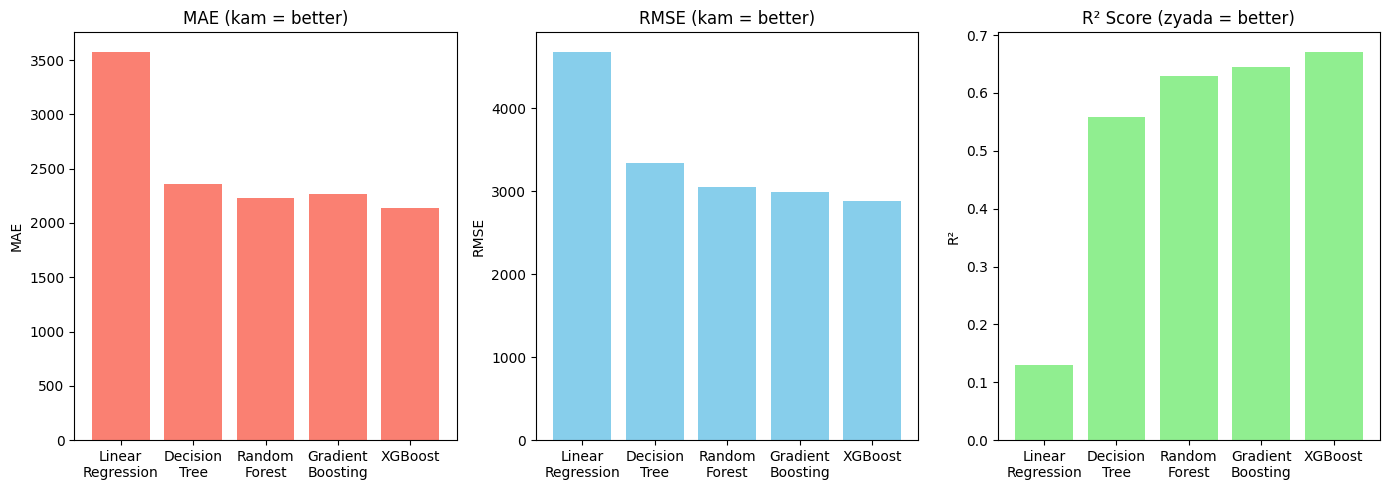

In [60]:
models = ["Linear\nRegression", "Decision\nTree", "Random\nForest", "Gradient\nBoosting", "XGBoost"]

def get_metrics(model, X_test, y_test):
	pred = model.predict(X_test)
	mae = mean_absolute_error(y_test, pred)
	rmse = np.sqrt(mean_squared_error(y_test, pred))
	r2 = r2_score(y_test, pred)
	return mae, rmse, r2

mae_lr, rmse_lr, r2_lr = get_metrics(lr, X_test, y_test)
mae_dt, rmse_dt, r2_dt = get_metrics(dt, X_test, y_test)
mae_rf, rmse_rf, r2_rf = get_metrics(rf, X_test, y_test)
mae_gb, rmse_gb, r2_gb = get_metrics(gbr, X_test, y_test)
mae_xgb, rmse_xgb, r2_xgb = get_metrics(xgb, X_test, y_test)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# MAE chart (kam = better)
axes[0].bar(models, [mae_lr, mae_dt, mae_rf, mae_gb, mae_xgb], color='salmon')
axes[0].set_title("MAE (kam = better)")
axes[0].set_ylabel("MAE")

# RMSE chart (kam = better)
axes[1].bar(models, [rmse_lr, rmse_dt, rmse_rf, rmse_gb, rmse_xgb], color='skyblue')
axes[1].set_title("RMSE (kam = better)")
axes[1].set_ylabel("RMSE")

# R² chart (zyada = better)
axes[2].bar(models, [r2_lr, r2_dt, r2_rf, r2_gb, r2_xgb], color='lightgreen')
axes[2].set_title("R² Score (zyada = better)")
axes[2].set_ylabel("R²")

plt.tight_layout()
plt.show()

In [61]:
import joblib
joblib.dump(xgb, 'purchase_prediction_model_xgb.pkl')
print("Model saved as 'purchase_prediction_model_xgb.pkl'")

Model saved as 'purchase_prediction_model_xgb.pkl'


In [62]:
print(X.drop('Product_ID', axis=1).columns.tolist())

['Gender', 'Age', 'Occupation', 'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3', 'B', 'C']


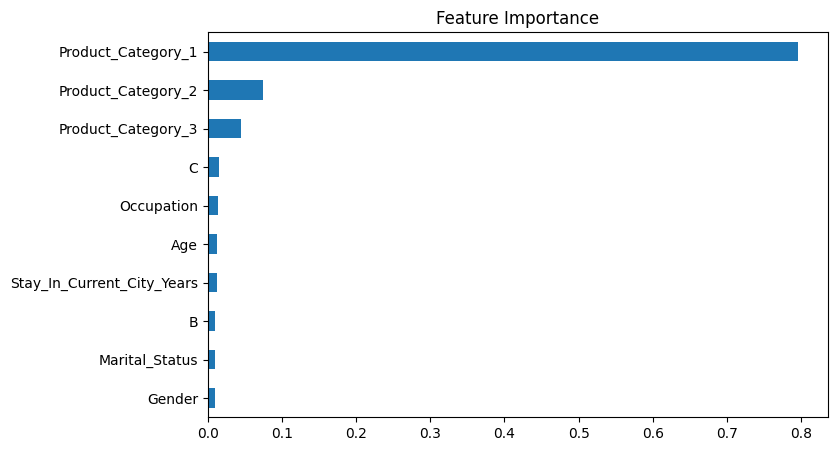

In [63]:
feature_names = X.drop('Product_ID', axis=1).columns
feat_imp = pd.Series(xgb.feature_importances_, index=feature_names)
feat_imp.sort_values().plot(kind='barh', figsize=(8, 5))
plt.title("Feature Importance")
plt.show()

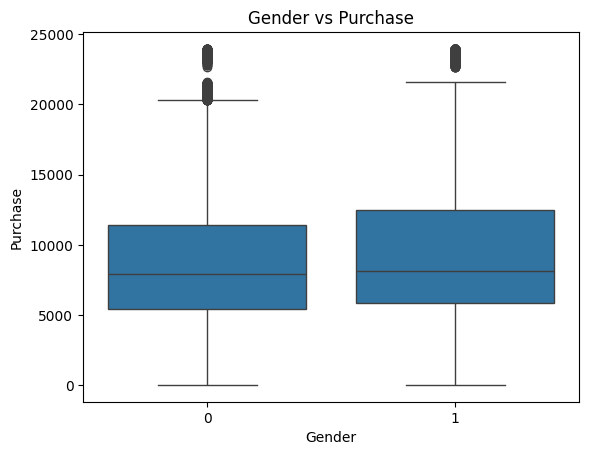

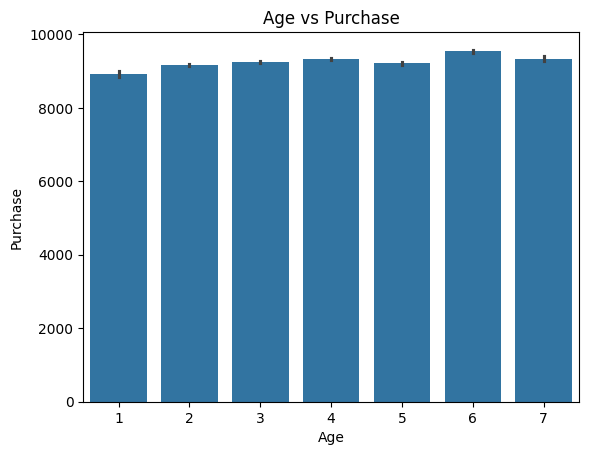

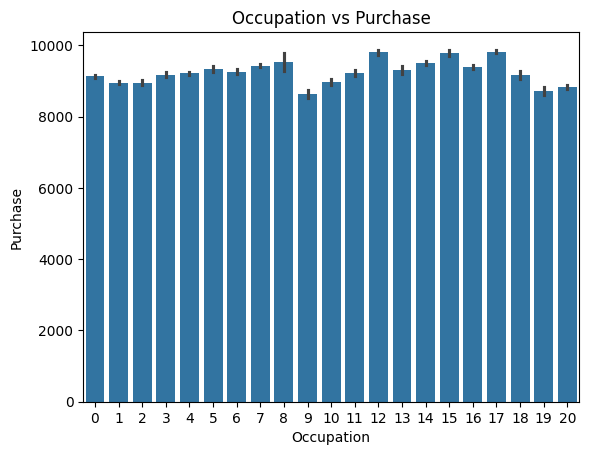

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

# Gender vs Purchase
sns.boxplot(x='Gender', y='Purchase', data=df)
plt.title("Gender vs Purchase")
plt.show()

# Age vs Purchase
sns.barplot(x='Age', y='Purchase', data=df)
plt.title("Age vs Purchase")
plt.show()

# City vs Purchase
sns.barplot(x='Occupation', y='Purchase', data=df)
plt.title("Occupation vs Purchase")
plt.show()

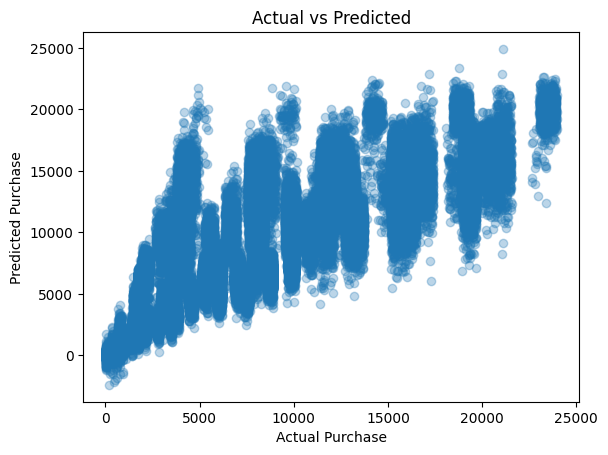

In [65]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Purchase")
plt.ylabel("Predicted Purchase")
plt.title("Actual vs Predicted")
plt.show()